Task 4
1. Create a new Python file, importing both cv2 and matplotlib.pyplot.
2. Read in the image from Task 1 and convert it from a BGR colour space to an RGB colour
space using the flag cv.COLOR_BGR2RGB.
3. Using plt.imshow(), create a plot with the image containing an appropriate title and other
useful annotations.
4. Extension - Try showing the image on matplotlib without applying the colour space
transformation and see what it looks like.
5. Extension - Try converting from BGR to a different colour space than RGB, such as HSV
or Grayscale and display it using matplotlib.
As a side note, if you hover your mouse over the matplotlib plot you displayed, you can see some
values in the bottom right corner. `x` and `y` are the (x,y) coordinates of the pixel under your
mouse tip, while the values below are the value of the pixel itself. These pixel values come in
handy particularly when thresholding images which we will see in a later lesson.

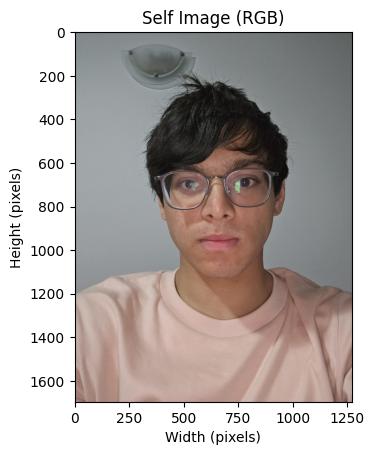

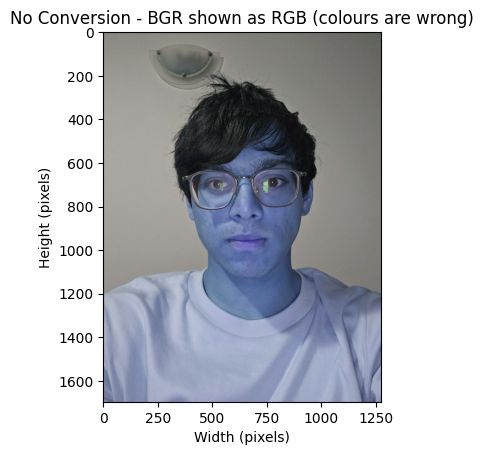

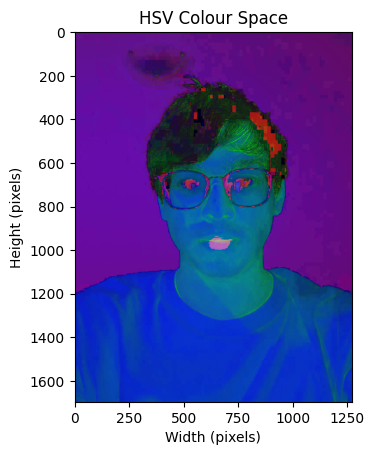

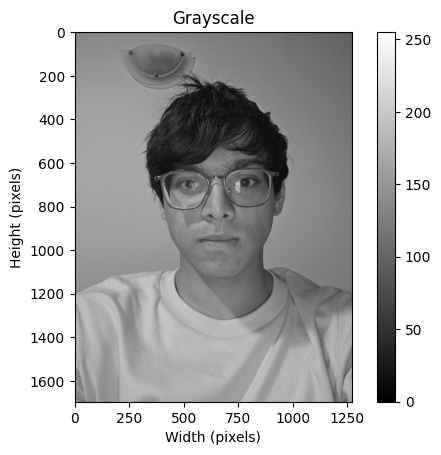

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

# Task 4: BGR to RGB 
img_bgr = cv.imread("FASTR_SelfImage.jpeg")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Self Image (RGB)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

# Extension 1: No colour conversion (BGR displayed as RGB)
plt.imshow(img_bgr)
plt.title("No Conversion - BGR shown as RGB (colours are wrong)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

# Extension 2: HSV colour space 
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

plt.imshow(img_hsv)
plt.title("HSV Colour Space")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()

# Extension 2: Grayscale
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")  # cmap="gray" needed for correct grayscale display
plt.title("Grayscale")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.colorbar()  # shows pixel intensity scale
plt.show()

Extension:
Create a user interface for displaying videos using cv.waitKey() and the keyboard. Some extra
additions to the interface my include adding a pause button, a reset button or a button which
displays the frame on matplotlib.

In [ ]:
def rescale(frame, scale):
    # Multiply original height and width by the scale factor
    height = int(frame.shape[0] * scale)
    width = int(frame.shape[1] * scale)
    dim = (width, height)
    # Resize the image to the new dimensions 
    return cv.resize(frame, dim, interpolation=cv.INTER_AREA)

# Open the webcam (0 = first camera); replace 0 with "video.mp4" for a file
capture = cv.VideoCapture(0)

# Track whether the video is paused or playing
paused = False

while True:
    # Only read a new frame if the video is not paused
    if paused == False:
        # Read the next frame from the webcam/video
        retval, frame = capture.read()

        # If no frame was returned (end of video or camera error), stop the loop
        if retval == False:
            break

    # Rescale the frame to 50% of its original size before displaying
    frame_resized = rescale(frame, 0.5)

    # Display the resized frame in a window titled "Video Player"
    cv.imshow("Video Player", frame_resized)

    # Wait 1ms and capture which key was pressed (0xFF masks to last 8 bits)
    key = cv.waitKey(1) & 0xFF

    if key == ord('d'):
        # 'D' pressed --> exit the loop and close the player
        break

    elif key == ord(' '):
        # SPACE pressed —-> toggle between paused and playing
        paused = not paused

    elif key == ord('m'):
        # 'M' pressed —> snapshot the current frame and show it in Matplotlib
        # Convert BGR (OpenCV format) to RGB (Matplotlib format) so colours are correct
        frame_rgb = cv.cvtColor(frame_resized, cv.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title("Captured Frame")
        plt.show()

# Release the webcam/video resource back to the operating system
capture.release()

# Close all OpenCV windows
cv.destroyAllWindows()